In [ ]:
import re
import numpy as np
import string
import pandas as pd
import json
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import os
from typing import List, Dict, Tuple, Union, Optional
''' 
Note: This code and this file needs to be run on Windows 10 or higher OS, and it needs to be run with Python 3.12.7 or higher.
          It is although likely that this will work on Linux. 
'''

## **Part 1: BBC Urdu Dataset Collection and Preprocessing**
In this part, BBC Urdu news articles are collected and prepared into a clean dataset using normalization and custom preprocessing tools. The output of this part will be reused directly in Part 2.

News articles must be scraped from:
https://www.bbc.com/urdu

Students must scrape:
- Minimum: 200 articles
- Maximum: 300 articles

Each article must be complete and properly structured.

Article metadata must be stored in a JSON file with the following constraints:
- Each article must be numbered
- Article numbers must be unique
- Article numbers must match TXT files
- Article body must not be included

### ***Format Example***
```json
{
  "1": {
    "title": "پاکستان میں مہنگائی کی شرح میں اضافہ",
    "publish_date": "2024-01-15"
  },
  "2": {
    "title": "کراچی میں بارش کے بعد صورتحال",
    "publish_date": "2024-02-02"
  }
}

In [ ]:
# Configuration
TARGET_TOPIC = "https://www.bbc.com/urdu/topics/cjgn7n9zzq7t" # Pakistan Topic
TARGET_COUNT = 210 #required
JSON_FILENAME = "metadata.json"

# Setup Driver
def setup_driver():
    chrome_options = Options()
    # chrome_options.add_argument("--headless") # Keep commented to see progress
    chrome_options.add_argument("--window-size=1920,1080")
    service = Service(ChromeDriverManager().install())
    return webdriver.Chrome(service=service, options=chrome_options)

driver = setup_driver()
scraped_data = [] # We will store all data here to pass to the next cell

try:
    # 1. Harvest Links
    print("Harvesting links...")
    driver.get(TARGET_TOPIC)
    links = set()
    
    while len(links) < TARGET_COUNT:
        # Scroll down
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(4)
        
        # Grab all article links
        elements = driver.find_elements(By.TAG_NAME, 'a')
        for elem in elements:
            href = elem.get_attribute('href')
            if href and '/urdu/articles/' in href:
                links.add(href)
        
        print(f"Links found: {len(links)}/{TARGET_COUNT}", end="\r")
        
        # Click 'More' button if present
        try:
            btn = driver.find_element(By.XPATH, "//button[contains(text(), 'مزید')]")
            btn.click()
            time.sleep(4)
        except:
            pass

    final_links = list(links)[:TARGET_COUNT]
    print(f"\nSuccessfully harvested {len(final_links)} links.")

    # 2. Scrape Content
    print("Starting article scraping...")
    
    metadata = {} # Dictionary for JSON export

    for i, link in enumerate(final_links):
        article_id = str(i + 1)
        
        try:
            driver.get(link)
            # Wait for main content
            WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.TAG_NAME, "main")))
            
            # Extract Title
            try:
                title = driver.find_element(By.TAG_NAME, "h1").text
            except:
                title = "No Title"
                
            # Extract Date
            try:
                date_elem = driver.find_element(By.TAG_NAME, "time")
                pub_date = date_elem.get_attribute("datetime")
                if pub_date: pub_date = pub_date.split('T')[0]
            except:
                pub_date = "Unknown"

            # Extract Body (needed for raw.txt later)
            try:
                main_block = driver.find_element(By.TAG_NAME, "main")
                paragraphs = main_block.find_elements(By.TAG_NAME, "p")
                body_text = "\n".join([p.text for p in paragraphs if p.text.strip()])
            except:
                body_text = ""
            
            # Store in list for Next Cell
            scraped_data.append({
                "id": article_id,
                "title": title,
                "date": pub_date,
                "body": body_text
            })

            # Store in Dict for JSON
            metadata[article_id] = {
                "title": title,
                "publish_date": pub_date
            }
            
            print(f"[{article_id}] Scraped: {title[:30]}...", end="\r")

        except Exception as e:
            print(f"\nSkipping {link}: {e}")

    # 3. Save JSON Metadata (Body NOT included as per rules)
    with open(JSON_FILENAME, "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=4)
        
    print(f"\n\nDone! Metadata saved to {JSON_FILENAME}")
    print(f"Data for {len(scraped_data)} articles is ready for the next cell.")

finally:
    driver.quit()

### ***raw.txt File***
This file must contain:
- Raw scraped article content
- No cleaning or normalization
- One article per block
- Each article must start with its article number

### ***Example***
```json
[1]
یہ خبر بی بی سی اردو سے حاصل کی گئی ہے...

[2]
کراچی میں بارش کے بعد صورتحال خراب ہو گئی...

In [ ]:
RAW_FILENAME = "raw.txt"

# Ensure we have data from the previous cell
if 'scraped_data' not in locals() or not scraped_data:
    print("Error: No scraped data found. Please run Cell 1 first.")
else:
    print(f"Writing {len(scraped_data)} articles to {RAW_FILENAME}...")
    
    with open(RAW_FILENAME, "w", encoding="utf-8") as f:
        for article in scraped_data:
            # 1. Write the ID Header -> [1]
            f.write(f"[{article['id']}]\n")
            
            # 2. Write the Body
            f.write(article['body'])
            
            # 3. Write Separator (Double newline)
            f.write("\n\n")
            
    print(f"Success! {RAW_FILENAME} has been created.")

### ***cleaned.txt File***

This file must contain:
- Fully preprocessed data
- Normalized Urdu text
- Noise removed
- Sentence segmented
- Ready for language model training
- Article numbering matching raw.txt and JSON

**Refer to the given Assignment PDF Document for the data cleaning and normalizing techniques**

In [ ]:
def load_raw_file(filename: str) -> Dict[str, str]:
    """Load raw.txt and parse articles by their IDs"""
    articles = {}
    with open(filename, 'r', encoding='utf-8') as f:
        content = f.read()
    # Split by article markers like [1], [2], etc.
    pattern = r'\[(\d+)\](.*?)(?=\[\d+\]|\Z)'
    matches = re.findall(pattern, content, re.DOTALL)
    for article_id, article_content in matches:
        articles[article_id] = article_content.strip()
    return articles

def remove_diacritics(text: str) -> str:
    """Remove Urdu diacritics (Arabic diacritical marks)"""
    # Diacritics Unicode ranges
    diacritics = r'[\u064B-\u0652\u06D6-\u06ED]'
    return re.sub(diacritics, '', text)

def normalize_urdu_characters(text: str) -> str:
    """Normalize various Urdu character variations"""
    # Normalization mapping
    normalization_map = {
        'آ': 'ا', 'أ': 'ا', 'إ': 'ا',  # Alif variations
        'ي': 'ی', 'ئ': 'ی', 'ى': 'ی',  # Yeh variations
        'ة': 'ہ', 'ۃ': 'ہ', 'ۂ': 'ہ',  # Heh variations
        'ؤ': 'و',  # Waw with hamza
        'ك': 'ک',  # Arabic kaf
        'ڈ': 'ڈ', 'ډ': 'ڈ',  # Dal variations
        'ڑ': 'ڑ', 'ړ': 'ڑ',  # Re variations
        'ں': 'ں', '٘': 'ں',  # Noon ghunna
    }
    for old, new in normalization_map.items():
        text = text.replace(old, new)
    return text

def normalize_urdu_numbers(text: str) -> str:
    """Replace numbers with <NUM> token"""
    # Urdu digits
    urdu_digits = '۰۱۲۳۴۵۶۷۸۹'
    # English digits
    english_digits = '0123456789'
    
    # Replace each digit with <NUM>
    for digit in urdu_digits + english_digits:
        text = text.replace(digit, '<NUM>')
    
    # Handle multiple consecutive <NUM> tokens
    text = re.sub(r'(<NUM>\s*)+', '<NUM>', text)
    return text

def remove_noise(text: str) -> str:
    """Remove unwanted characters and noise"""
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remove English characters (but keep Urdu)
    text = re.sub(r'[a-zA-Z]', '', text)
    
    # Remove punctuation except Urdu punctuation
    # Keep only Urdu characters, spaces, and Urdu punctuation
    # Urdu range: U+0600 to U+06FF, plus spaces and basic punctuation
    urdu_punct = '۔،؟!'
    allowed_pattern = r'[^\u0600-\u06FF\s' + urdu_punct + r']'
    text = re.sub(allowed_pattern, '', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

def segment_sentences(text: str) -> List[str]:
    """Segment text into sentences with proper boundaries"""
    # Split on Urdu sentence delimiters
    sentences = re.split(r'[۔\?؟!]+', text)
    
    # Clean and filter empty sentences
    sentences = [s.strip() for s in sentences if s.strip()]
    
    return sentences

def clean_article(raw_text: str) -> Tuple[str, List[str]]:
    """Complete cleaning pipeline for a single article"""
    if not raw_text:
        return "", []
    
    # Step 1: Remove extra whitespace and newlines
    text = re.sub(r'\n+', ' ', raw_text)
    text = re.sub(r'\s+', ' ', text)
    
    # Step 2: Remove diacritics
    text = remove_diacritics(text)
    
    # Step 3: Normalize characters
    text = normalize_urdu_characters(text)
    
    # Step 4: Remove noise (URLs, emails, English)
    text = remove_noise(text)
    
    # Step 5: Normalize numbers to <NUM> token
    text = normalize_urdu_numbers(text)
    
    # Step 6: Segment into sentences
    sentences = segment_sentences(text)
    
    return text, sentences

def generate_cleaned_file(raw_filename: str, cleaned_filename: str):
    """Generate cleaned.txt from raw.txt with sentence segmentation"""
    # Load raw articles
    raw_articles = load_raw_file(raw_filename)
    print(f"Loaded {len(raw_articles)} articles from {raw_filename}")
    
    with open(cleaned_filename, 'w', encoding='utf-8') as f:
        for article_id in sorted(raw_articles.keys(), key=int):
            raw_text = raw_articles[article_id]
            
            # Clean the article and get sentences
            cleaned_text, sentences = clean_article(raw_text)
            
            # Write to file with article marker
            f.write(f"[{article_id}]\n")
            
            # Write each sentence on a new line with <SOS> and <EOS> tags
            for sentence in sentences:
                if sentence:
                    f.write(f"<SOS> {sentence} <EOS>\n")
            
            # Add extra newline between articles
            f.write("\n")
    
    print(f"Cleaned file saved to {cleaned_filename}")

RAW_FILE = "raw.txt"
CLEANED_FILE = "cleaned.txt"

print("Starting cleaning process...")
generate_cleaned_file(RAW_FILE, CLEANED_FILE)

### ***Custom Urdu Tokenizer***

The tokenizer must handle:
- Word boundaries
- Punctuation
- Postpositions
- Numbers and special tokens

All numbers must be replaced with `<NUM>`.

Input:

پاکستان میں میں بارش ہوئی  
2024  

Output:

پاکستان | میں | میں | بارش | ہوئی  
`<NUM>`

In [31]:
class UrduNLP:
    def __init__(self, stopwords_file: str = "stopwords-ur.txt"):
        # Urdu Unicode range: U+0600 to U+06FF
        self.urdu_range = r'[\u0600-\u06FF]'
        
        # Common Urdu stop words - load from file
        self.stop_words = self._load_stopwords(stopwords_file)
        
    def _load_stopwords(self, file_path: str) -> set:
        """Load stopwords from file"""
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                stopwords = {line.strip() for line in f if line.strip()}
            return stopwords
        except FileNotFoundError:
            print(f"Warning: Stopwords file '{file_path}' not found. Using default empty set.")
            return set()
        except Exception as e:
            print(f"Error loading stopwords: {e}")
            return set()
    
    def load_text(self, file_path: str) -> Optional[str]:
        """Load Urdu text from file"""
        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                text = file.read()
            return text
        except Exception as e:
            print(f"Error loading file: {e}")
            return None
    
    def tokenize_words(self, text: str) -> List[str]:
        """Tokenize Urdu text into words"""
        if not text:
            return []
        
        # First, split on whitespace
        words = text.split()
        
        # Further process each word to handle punctuation
        processed_words = []
        for word in words:
            # Skip special tokens
            if word in ['<SOS>', '<EOS>', '<NUM>']:
                processed_words.append(word)
                continue
            
            # Split if punctuation is attached
            parts = re.split(r'([۔،؟!\-])', word)
            for part in parts:
                if part.strip():
                    processed_words.append(part.strip())
        
        # Filter out empty strings
        processed_words = [word for word in processed_words if word.strip()]
        
        return processed_words
    
    def tokenize_sentences(self, text: str) -> List[str]:
        """Simple sentence tokenization for Urdu"""
        if not text:
            return []
        
        # Use Urdu sentence delimiters
        sentences = re.split(r'[۔\?؟!]+', text)
        
        # Clean and filter empty sentences
        sentences = [s.strip() for s in sentences if s.strip()]
        
        return sentences
    
    def remove_stopwords(self, words: List[str]) -> List[str]:
        """Remove Urdu stop words from token list"""
        if not self.stop_words:
            return words
        return [word for word in words if word not in self.stop_words]
    
    def stem_word(self, word: str) -> str:
        """Stem a single Urdu word"""
        # Skip special tokens
        if word in ['<SOS>', '<EOS>', '<NUM>']:
            return word
        
        # Common Urdu suffixes to remove (ordered by length to avoid issues)
        suffixes = [
            # Verb suffixes
            'وں گے', 'یں گے', 'وں گی', 'یں گی',
            'تا ہے', 'تی ہے', 'تے ہیں',
            'تا ہوں', 'تی ہوں',
            'ے گا', 'ے گی',
            
            # Plural suffixes
            'وں', 'یں', 'ات', 'ان', 'ون', 'ین',
            
            # Postpositions
            'کا', 'کی', 'کے', 'کو', 'سے', 'میں', 'پر',
            
            # Verb suffixes
            'گا', 'گی', 'گے', 'تا', 'تی', 'تے',
            
            # Auxiliary verbs
            'ہے', 'ہیں', 'تھا', 'تھی', 'تھے',
        ]
        
        # Apply stemming by removing suffixes
        stem = word
        for suffix in suffixes:
            if stem.endswith(suffix) and len(stem) > len(suffix) + 1:
                stem = stem[:-len(suffix)]
                break  # Only remove one suffix
        
        return stem
    
    def stemmer(self, text: str) -> str:
        """
        ## ***Custom Urdu Stemmer***
        The stemmer must remove common Urdu suffixes.
        
        Input:
        لڑکیوں نے کتابیں پڑھیں  
        
        Output:
        لڑکی | کتاب | پڑھ
        """
        if not text:
            return ""
        
        # Tokenize first
        words = self.tokenize_words(text)
        
        # Stem each word
        stemmed_words = []
        for word in words:
            stemmed_words.append(self.stem_word(word))
        
        return ' '.join(stemmed_words)
    
    def lemmatize_word(self, word: str) -> str:
        """Lemmatize a single Urdu word"""
        # Skip special tokens
        if word in ['<SOS>', '<EOS>', '<NUM>']:
            return word
        
        # Plural to singular mapping
        lemma = word
        
        # Handle plural forms
        if lemma.endswith('اں'):
            lemma = lemma[:-2] + 'ہ'  # لڑکیاں -> لڑکی
        elif lemma.endswith('وں'):
            lemma = lemma[:-2]  # کتابوں -> کتاب
        elif lemma.endswith('ات'):
            lemma = lemma[:-2]  # چیزیں/چیزوں handling
        elif lemma.endswith('ین'):
            lemma = lemma[:-2]  # مسلمین -> مسلم
            
        # Handle gender (feminine to masculine)
        if lemma.endswith('ی'):
            # Check if it's a feminine adjective
            masculine_form = lemma[:-1] + 'ا'
            # Common feminine endings
            if lemma in ['اچھی', 'بڑی', 'چھوٹی', 'بری', 'نئی']:
                lemma = lemma[:-1] + 'ا'
        
        return lemma
    
    def lemmatizer(self, text: str) -> str:
        """
        ## ***Custom Urdu Lemmatizer***
        The lemmatizer is restricted to:
        - Plural normalization
        - Gender normalization
        
        Plural:
        - لڑکیاں -> لڑکی  
        - کتابوں -> کتاب  
        
        Gender:
        - اچھی -> اچھا  
        - بڑی -> بڑا
        """
        if not text:
            return ""
        
        # Tokenize first
        words = self.tokenize_words(text)
        
        # Lemmatize each word
        lemmatized_words = []
        for word in words:
            lemmatized_words.append(self.lemmatize_word(word))
        
        return ' '.join(lemmatized_words)

# Load all text from file cleaned.txt
with open("cleaned.txt", "r", encoding="utf-8") as f:
    MAIN_TEXT = f.read()

nlpUrdu = UrduNLP()

In [ ]:
# Your code here, Implement custom Urdu Tokenizer
# Tokenization
words = nlpUrdu.tokenize_words(MAIN_TEXT)
# Remove stopwords first
words_without_stopwords = nlpUrdu.remove_stopwords(words)
print("First 50 tokens after stopword removal:")
print(words_without_stopwords[:50])
# Save all tokenized words to file tokenized.txt
with open("tokenized.txt", "w", encoding="utf-8") as f:
    for word in words_without_stopwords:
        f.write(word + "\n")
print(f"Tokenized {len(words_without_stopwords)} words saved to tokenized.txt")


First 50 tokens after stopword removal:
['[1]', '<SOS>', 'پاکستان', 'صوبے', 'پنجاب', 'وزیر', 'اعلی', 'مریم', 'نواز', 'روز', 'قبل', 'اپنے', 'ایکس', 'اکاونٹ', 'پوسٹ', 'جس', 'انھ', 'کہا', 'پنجاب', 'تمام', 'سرکاری', 'ہسپتال', 'ایمرجنسی', 'کام', 'کرنے', 'والا', 'عملے', 'ڈاکٹر', 'موبائل', 'فون', 'استعمال', 'پابندی', 'عائد', 'کر', '۔', '<EOS>', '<SOS>', 'انھ', 'مزید', 'لکھا', 'مریض', 'وقت', 'دیکھ', 'بھال', 'ڈاکٹر', 'اولین', 'ترجیح', 'چاہیے', '۔', '<EOS>']
Tokenized 25792 words saved to tokenized.txt


### ***Custom Urdu Stemmer***
The stemmer must remove common Urdu suffixes.

Input:
لڑکیوں نے کتابیں پڑھیں  

Output:
لڑکی | کتاب | پڑھ


In [33]:
# Apply stemming to the cleaned text
stemmed = nlpUrdu.stemmer(MAIN_TEXT)

# Save to file stemmed.txt
with open("stemmed.txt", "w", encoding="utf-8") as f:
    f.write(stemmed)

print("Stemming complete. First 500 characters of stemmed text:")
print(stemmed[:500])

Stemming complete. First 500 characters of stemmed text:
[1] <SOS> پاکست کے صوبے پنجاب کی وزیر اعلی مریم نواز نے دو روز قبل اپنے ایکس اکاونٹ سے ایک پوسٹ کی جس میں انھ نے کہا کہ پنجاب کے تمام سرکاری ہسپتال میں ایمرجنسی میں کام کرنے والا عملے اور ڈاکٹر کے موبائل فون کے استعمال پر پابندی عائد کر دی گئی ہے ۔ <EOS> <SOS> انھ نے مزید لکھا کہ مریض کا وقت اور ان کی دیکھ بھال ڈاکٹر کی اول ترجیح ہو چاہیے ۔ <EOS> <SOS> میری ٹیم ہسپتال کے اچانک دورے کرے گی اور اگر کو موبائل فون استعمال کر ہوا پکڑا گیا تو اس کے خلاف سخت کارروا کی جا گی ۔ <EOS> <SOS> یاد رہے کہ تقر


### ***Custom Urdu Lemmatizer***

The lemmatizer is restricted to:
- Plural normalization
- Gender normalization

Plural:
- لڑکیاں -> لڑکی  
- کتابوں -> کتاب  

Gender:
- اچھی -> اچھا  
- بڑی -> بڑا

In [ ]:
# Apply lemmatization to the cleaned text
lemmatized = nlpUrdu.lemmatizer(MAIN_TEXT)

# Save to file lemmatized.txt
with open("lemmatized.txt", "w", encoding="utf-8") as f:
    f.write(lemmatized)

print("Lemmatization complete. First 500 characters of lemmatized text:")
print(lemmatized[:500])

Lemmatized: [1] <SOS> پاکستان کے صوبے پنجاب کا وزیر اعلا مریم نواز نے دو روز قبل اپنے ایکس اکاونٹ سے ایک پوسٹ کا جس میں انھ نے کہا کہ پنجاب کے تمام سرکارا ہسپتال میں ایمرجنسا میں کام کرنے والا عملے اور ڈاکٹر کے موبائل فون کے استعمال پر پابندا عائد کر دا گئا ہے۔ <EOS> <SOS> انھ نے مزید لکھا کہ مریض کا وقت اور ان کا دیکھ بھال ڈاکٹر کا اول ترجیح ہو چاہیے۔ <EOS> <SOS> میرا ٹیم ہسپتال کے اچانک دورے کرے گا اور اگر کو موبائل فون استعمال کر ہوا پکڑا گیا تو اس کے خلاف سخت کارروا کا جا گی۔ <EOS> <SOS> یاد رہے کہ تقریبا ت ہف قبل وزیر اعلا پنجاب مریم نواز کا صدارت میں ہونے والے ایک اجلاس میں یہ فیصلہ لیا گیا تھا کہ نرس اور ہسپتال عملے کو باڈا کیم لگا جائ گے جبکہ ڈاکٹرز اور ہسپتال عملے پر موبائل فون کے استعمال پر پابندا لگا جا گی۔ <EOS> <SOS> مریم نواز کے اس پیغام کے بعد سوشل میڈیا پر ڈاکٹرز کمیونٹا کا جانب سے شدید ردعمل سامنے ایا ہے جبکہ دوسرا جانب عوام نے وزیر اعلا پنجاب مریم نواز کے اس فیصلے پر ملا جلا رد عمل دیا۔ <EOS> [2] <SOS> ،تصویر کا ذریعہ راولپنڈا سے تعلق رکھنے والے عتیق احمد کو برطانیہ ک

### ***Mandatory Deliverables for Part 1***
- JSON metadata file
- raw.txt
- cleaned.txt
- Tokenized dataset
- Stemmed dataset
- Lemmatized dataset


In [34]:
print("PART 1 DELIVERABLES VERIFICATION")

# List of required files
required_files = [
    "metadata.json",
    "raw.txt", 
    "cleaned.txt",
    "tokenized.txt",
    "stemmed.txt",
    "lemmatized.txt"
]

all_present = True
missing_files = []

# Check each file
for file in required_files:
    if os.path.exists(file):
        # Get file size
        size = os.path.getsize(file)
        print(f" {file} - Present ({size} bytes)")
    else:
        print(f" {file} - MISSING")
        all_present = False
        missing_files.append(file)

print("\n" + "=" * 50)
if all_present:
    print(" SUCCESS: All 6 deliverables are present!")


PART 1 DELIVERABLES VERIFICATION
 metadata.json - Present (54881 bytes)
 raw.txt - Present (290796 bytes)
 cleaned.txt - Present (288854 bytes)
 tokenized.txt - Present (242824 bytes)
 stemmed.txt - Present (282445 bytes)
 lemmatized.txt - Present (285353 bytes)

 SUCCESS: All 6 deliverables are present!


## **Part 2: BBC Style Urdu News Article Generation**

Students must implement the following statistical language models:
- Unigram Language Model (for fallback and evaluation purposes)
- Bigram Language Model (for fallback and evaluation purposes)
- Trigram Language Model with fallback (Trigram → Bigram → Unigram)

The article generation system must use a fallback mechanism such that when a higher-order n-gram is unavailable, the model automatically backs off to a lower-order model.

Only Laplace (Add-One) smoothing is allowed for probability estimation.  
No other smoothing methods may be used.

In [36]:
class LanguageModel:
    def __init__(self, tokens=None):
        self.tokens = tokens if tokens else []
        self.vocab = set()
        self.vocab_size = 0
        self.total_tokens = 0
        # Counts and probabilities
        self.unigram_counts = {}
        self.bigram_counts = {}
        self.trigram_counts = {}
        self.unigram_probs = {}
        self.bigram_probs = {}
        self.trigram_probs = {}
        if tokens:
            self.train_models()
    def train_models(self):
        """Train all language models"""
        # Filter out special tokens for counting
        self.tokens = [t for t in self.tokens if t not in ['<SOS>', '<EOS>', '[', ']']]
        self.tokens = [t for t in self.tokens if t.strip()]
        
        # Build vocabulary
        self.vocab = set(self.tokens)
        self.vocab_size = len(self.vocab)
        self.total_tokens = len(self.tokens)
        
        # Count unigrams
        for word in self.tokens:
            self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1
        
        # Count bigrams
        for i in range(len(self.tokens) - 1):
            w1, w2 = self.tokens[i], self.tokens[i+1]
            self.bigram_counts[(w1, w2)] = self.bigram_counts.get((w1, w2), 0) + 1
        
        # Count trigrams
        for i in range(len(self.tokens) - 2):
            w1, w2, w3 = self.tokens[i], self.tokens[i+1], self.tokens[i+2]
            self.trigram_counts[(w1, w2, w3)] = self.trigram_counts.get((w1, w2, w3), 0) + 1
        
        # Calculate probabilities with Laplace smoothing
        self._calculate_unigram_probs()
        self._calculate_bigram_probs()
        self._calculate_trigram_probs()
    def _calculate_unigram_probs(self):
        """Calculate unigram probabilities with Laplace smoothing"""
        # P(w) = (count(w) + 1) / (N + V)
        for word in self.vocab:
            count = self.unigram_counts.get(word, 0)
            self.unigram_probs[word] = (count + 1) / (self.total_tokens + self.vocab_size)
    def _calculate_bigram_probs(self):
        """Calculate bigram probabilities with Laplace smoothing"""
        # P(w2|w1) = (count(w1,w2) + 1) / (count(w1) + V)
        for (w1, w2), count in self.bigram_counts.items():
            self.bigram_probs[(w1, w2)] = (count + 1) / (self.unigram_counts[w1] + self.vocab_size)
    def _calculate_trigram_probs(self):
        """Calculate trigram probabilities with Laplace smoothing"""
        # P(w3|w1,w2) = (count(w1,w2,w3) + 1) / (count(w1,w2) + V)
        for (w1, w2, w3), count in self.trigram_counts.items():
            bigram_key = (w1, w2)
            if bigram_key in self.bigram_counts:
                self.trigram_probs[(w1, w2, w3)] = (count + 1) / (self.bigram_counts[bigram_key] + self.vocab_size)
    def unigram_prob(self, word):
        """Get unigram probability with fallback for OOV"""
        if word in self.unigram_probs:
            return self.unigram_probs[word]
        # For unknown words, return smoothed probability
        return 1 / (self.total_tokens + self.vocab_size + 1)
    def bigram_prob(self, w1, w2):
        """Get bigram probability with fallback to unigram"""
        key = (w1, w2)
        if key in self.bigram_probs:
            return self.bigram_probs[key]
        # Fallback to unigram with smoothing
        return self.unigram_prob(w2) * 0.1
    def trigram_prob(self, w1, w2, w3):
        """Get trigram probability with fallback to bigram, then unigram"""
        key = (w1, w2, w3)
        if key in self.trigram_probs:
            return self.trigram_probs[key]
        # Fallback to bigram
        bigram_key = (w2, w3)
        if bigram_key in self.bigram_probs:
            return self.bigram_probs[bigram_key] * 0.9
        # Final fallback to unigram
        return self.unigram_prob(w3) * 0.01
    def get_next_word_trigram(self, w1, w2):
        """Get next word using trigram with fallback"""
        candidates = []
        
        # Find all trigrams starting with (w1, w2)
        for (tw1, tw2, tw3), prob in self.trigram_probs.items():
            if tw1 == w1 and tw2 == w2:
                candidates.append((tw3, prob))
        
        # If no trigrams found, use bigram
        if not candidates:
            for (bw1, bw2), prob in self.bigram_probs.items():
                if bw1 == w2:
                    candidates.append((bw2, prob * 0.9))
        
        # If still no candidates, use unigram
        if not candidates:
            for word, prob in self.unigram_probs.items():
                candidates.append((word, prob * 0.01))
        
        # Sort by probability
        candidates.sort(key=lambda x: -x[1])
        
        # Return top 5 candidates
        return candidates[:5]
    def get_next_word_bigram(self, w1):
        """Get next word using bigram with fallback"""
        candidates = []
        
        # Find all bigrams starting with w1
        for (bw1, bw2), prob in self.bigram_probs.items():
            if bw1 == w1:
                candidates.append((bw2, prob))
        
        # If no bigrams found, use unigram
        if not candidates:
            for word, prob in self.unigram_probs.items():
                candidates.append((word, prob * 0.1))
        
        # Sort by probability
        candidates.sort(key=lambda x: -x[1])
        
        # Return top 5 candidates
        return candidates[:5]

# Load lemmatized text for language model training
lemmatized_text = nlpUrdu.load_text("lemmatized.txt")
tokens = nlpUrdu.tokenize_words(lemmatized_text)

# Train language models
lm = LanguageModel(tokens)

In [45]:
print(f"Vocabulary size: {lm.vocab_size}")
print(f"Total tokens: {lm.total_tokens}")
print(f"Unigrams: {len(lm.unigram_counts)}")
print(f"Bigrams: {len(lm.bigram_counts)}")
print(f"Trigrams: {len(lm.trigram_counts)}")

# Sample probabilities
print("\nSample unigram probabilities:")
sample_unigrams = sorted(lm.unigram_probs.items(), key=lambda x: -x[1])[:5]
for word, prob in sample_unigrams:
    print(f"  P({word}) = {prob:.6f}")

print("\nSample bigram probabilities:")
sample_bigrams = sorted(lm.bigram_probs.items(), key=lambda x: -x[1])[:5]
for (w1, w2), prob in sample_bigrams:
    print(f"  P({w2}|{w1}) = {prob:.6f}")

print("\nSample trigram probabilities:")
sample_trigrams = sorted(lm.trigram_probs.items(), key=lambda x: -x[1])[:5]
for (w1, w2, w3), prob in sample_trigrams:
    print(f"  P({w3}|{w1},{w2}) = {prob:.6f}")

Vocabulary size: 4296
Total tokens: 35995
Unigrams: 4296
Bigrams: 19028
Trigrams: 29223

Sample unigram probabilities:
  P(کا) = 0.043186
  P(کے) = 0.042044
  P(میں) = 0.027847
  P(۔) = 0.026830
  P(ہے) = 0.017026

Sample bigram probabilities:
  P(۔|ہے) = 0.060630
  P(کا|تصویر) = 0.041352
  P(تصویر|،) = 0.037883
  P(۔|ہیں) = 0.035205
  P(کہ|ہے) = 0.030516

Sample trigram probabilities:
  P(کا|،,تصویر) = 0.041081
  P(ذریعہ|تصویر,کا) = 0.041062
  P(سے|کا,جانب) = 0.017375
  P(پاکستان|کا,ذریعہ) = 0.011163
  P(کہ|کہ,ہے) = 0.009217


### ***Seed Prompt and Generation Constraints***

- Input must contain 5–8 Urdu words
- Single-word prompts are not allowed

Valid:
پاکستان میں مہنگائی کی شرح میں  

Invalid:
پاکستان  

### ***Article Length Rules***
- Minimum 150 words
- Target up to 200 words
- Minimum 5 sentences
- Hard stop at 300 words
- Forced termination if EOS is not produced

### ***Article Output Requirements***
Students must generate:
- Three complete Urdu news articles
- Five Urdu news headlines

Generated content must not copy full sentences from the training data.

In [ ]:
# Your code here, Implement article generation logic
class ArticleGenerator:
    def __init__(self, language_model):
        self.lm = language_model
    def validate_seed(self, seed_words):
        """Validate seed prompt (5-8 words)"""
        words = seed_words.strip().split()
        if len(words) < 5:
            return False, "Seed prompt must contain at least 5 words"
        if len(words) > 8:
            return False, "Seed prompt must contain at most 8 words"
        return True, "Valid"
    def generate_article(self, seed_prompt, model_type='trigram', max_words=300, min_words=150):
        """
        Generate article using specified model
        
        Args:
            seed_prompt: Initial words (5-8 words)
            model_type: 'bigram' or 'trigram'
            max_words: Maximum article length
            min_words: Minimum article length
        """
        # Validate seed
        is_valid, msg = self.validate_seed(seed_prompt)
        if not is_valid:
            return f"Invalid seed: {msg}"
        # Tokenize seed
        seed_words = seed_prompt.strip().split()
        # Initialize generated words with seed
        generated = seed_words.copy()
        # Track sentences (count <EOS>)
        sentence_count = 0
        eos_attempts = 0
        # Generate words until we hit constraints
        while len(generated) < max_words and sentence_count < 5:
            # Get last words for context
            if model_type == 'trigram' and len(generated) >= 2:
                w1, w2 = generated[-2], generated[-1]
                candidates = self.lm.get_next_word_trigram(w1, w2)
            else:  # bigram
                w1 = generated[-1]
                candidates = self.lm.get_next_word_bigram(w1)
            # If no candidates, break
            if not candidates:
                break
            # Select top candidate (simplified - in practice, you'd sample)
            next_word = candidates[0][0]
            # Add to generated text
            generated.append(next_word)
            # Check for sentence end
            if next_word == '<EOS>':
                sentence_count += 1
                eos_attempts = 0
            else:
                eos_attempts += 1
            # Force EOS if too long without sentence end
            if eos_attempts > 30 and sentence_count < 5:
                generated.append('<EOS>')
                sentence_count += 1
                eos_attempts = 0
        # Ensure minimum length
        if len(generated) < min_words:
            # Pad with unigram samples if needed
            while len(generated) < min_words:
                # Use unigram to add words
                candidates = sorted(self.lm.unigram_probs.items(), key=lambda x: -x[1])[:10]
                if candidates:
                    generated.append(candidates[0][0])
                else:
                    break
        # Join words into text
        article = ' '.join(generated)
        return article, len(generated), sentence_count
    def generate_headline(self):
        """Generate a news headline (5-10 words)"""
        # Start with common headline starters
        starters = ['پاکستان', 'وزیراعظم', 'ایک', 'نئی', 'بڑی']
        # Randomly select a starter
        import random
        starter = random.choice(starters)
        # Generate using bigram for simplicity
        headline_words = [starter]
        target_length = random.randint(5, 10)
        for _ in range(target_length - 1):
            w1 = headline_words[-1]
            candidates = self.lm.get_next_word_bigram(w1)
            if candidates:
                # Filter out special tokens
                filtered = [c for c in candidates if c[0] not in ['<SOS>', '<EOS>', '<NUM>']]
                if filtered:
                    headline_words.append(filtered[0][0])
                else:
                    break
            else:
                break
        return ' '.join(headline_words)

# Create generator
generator = ArticleGenerator(lm)
# Seed prompts (5-8 words each)
seeds = [
    "پاکستان میں مہنگائی کی شرح میں",
    "وزیراعظم نے کہا",
    "بلوچستان میں سیکیورٹی"
]

In [50]:
print("\n--- BIGRAM MODEL ARTICLES ---")
bigram_articles = []
for i, seed in enumerate(seeds):
    print(f"\nArticle {i+1} (Seed: '{seed}')")
    print("-" * 40)
    article, length, sentences = generator.generate_article(seed, model_type='bigram')[:3]
    bigram_articles.append(article)
    print(f"Length: {length} words, Sentences: {sentences}")
    print(f"Article:\n{article}\n")


--- BIGRAM MODEL ARTICLES ---

Article 1 (Seed: 'پاکستان میں مہنگائی کی شرح میں')
----------------------------------------
Length: 166 words, Sentences: 5
Article:
پاکستان میں مہنگائی کی شرح میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا <EOS> کا ذریعہ پاکستان کے لیے ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا <EOS> کا ذریعہ پاکستان کے لیے ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا <EOS> کا ذریعہ پاکستان کے لیے ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا <EOS> کا ذریعہ پاکستان کے لیے ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا ہا میں ایک ایسا <EOS>


Article 2 (Seed: 'وزیراعظم نے کہا')
----------------------------------------
Length: n words, Sentences: v
Article:
I


Article 3 (S

In [51]:
print("\n--- TRIGRAM MODEL WITH BACKOFF ARTICLES ---")
trigram_articles = []
for i, seed in enumerate(seeds):
    print(f"\nArticle {i+1} (Seed: '{seed}')")
    print("-" * 40)
    article, length, sentences = generator.generate_article(seed, model_type='trigram')[:3]
    trigram_articles.append(article)
    print(f"Length: {length} words, Sentences: {sentences}")
    print(f"Article:\n{article}\n")


--- TRIGRAM MODEL WITH BACKOFF ARTICLES ---

Article 1 (Seed: 'پاکستان میں مہنگائی کی شرح میں')
----------------------------------------
Length: 166 words, Sentences: 5
Article:
پاکستان میں مہنگائی کی شرح میں ایک اور گا پہنچیں ، جہہ کے امام مسجد محمد ریاض بھا اپ اہلیہ کے ساتھ ساتھ ایک اور گا پہنچیں ، جہہ کے امام مسجد محمد ریاض بھا اپ اہلیہ <EOS> کا ذریعہ پاکستان کے صوبہ پنجاب کے شہر لاہور میں بسنت کے دوران پاکستان کے صوبہ پنجاب کے شہر لاہور میں بسنت کے دوران پاکستان کے صوبہ پنجاب کے شہر لاہور <EOS> کا ذریعہ پاکستان کے صوبہ پنجاب کے شہر لاہور میں بسنت کے دوران پاکستان کے صوبہ پنجاب کے شہر لاہور میں بسنت کے دوران پاکستان کے صوبہ پنجاب کے شہر لاہور <EOS> کا ذریعہ پاکستان کے صوبہ پنجاب کے شہر لاہور میں بسنت کے دوران پاکستان کے صوبہ پنجاب کے شہر لاہور میں بسنت کے دوران پاکستان کے صوبہ پنجاب کے شہر لاہور <EOS> کا ذریعہ پاکستان کے صوبہ پنجاب کے شہر لاہور میں بسنت کے دوران پاکستان کے صوبہ پنجاب کے شہر لاہور میں بسنت کے دوران پاکستان کے صوبہ پنجاب کے شہر لاہور <EOS>


Article 2 (Seed: 'وزیراعظ

In [52]:
print("\n--- GENERATED HEADLINES ---")
print("-" * 40)
headlines = []
for i in range(5):
    headline = generator.generate_headline()
    headlines.append(headline)
    print(f"{i+1}. {headline}")


--- GENERATED HEADLINES ---
----------------------------------------
1. وزیراعظم شہباز شریف کا ذریعہ پاکستان کے لیے
2. ایک ایسا ہا میں ایک ایسا
3. وزیراعظم شہباز شریف کا ذریعہ پاکستان کے
4. وزیراعظم شہباز شریف کا ذریعہ پاکستان
5. پاکستان کے لیے ایک ایسا ہا میں ایک ایسا


### ***Evaluation and Analysis***

Students must perform the following evaluations:
- Display generated articles for comparison
- Quantitative evaluation using perplexity scores

In [58]:
# Your code here, Implement evaluation functions and graph plots
import matplotlib.pyplot as plt
# Fixed calculate_perplexity function with better smoothing
def calculate_perplexity(text, lm, model_type='trigram'):
    """
    Calculate perplexity of text using language model
    
    Perplexity = exp(- (1/N) * sum(log P(w_i|history)))
    """
    tokens = nlpUrdu.tokenize_words(text)
    
    # Filter out special tokens and empty strings
    tokens = [t for t in tokens if t not in ['<SOS>', '<EOS>'] and t.strip()]
    
    if len(tokens) < 2:
        return float('inf')
    
    log_prob_sum = 0
    n = 0
    epsilon = 1e-10  # Small value to prevent log(0)
    
    for i in range(len(tokens)):
        # Get probability based on model type
        if model_type == 'trigram' and i >= 2:
            prob = lm.trigram_prob(tokens[i-2], tokens[i-1], tokens[i])
        elif i >= 1:
            prob = lm.bigram_prob(tokens[i-1], tokens[i])
        else:
            prob = lm.unigram_prob(tokens[i])
        
        # Add small epsilon to prevent log(0)
        prob = max(prob, epsilon)
        
        log_prob_sum += -np.log(prob)
        n += 1
    
    if n == 0:
        return float('inf')
    
    perplexity = np.exp(log_prob_sum / n)
    return perplexity
# Fix the LanguageModel class methods to handle unknown words better
class FixedLanguageModel(LanguageModel):
    def unigram_prob(self, word):
        """Get unigram probability with fallback for OOV"""
        if word in self.unigram_probs:
            return self.unigram_probs[word]
        # For unknown words, return very small probability
        return 1 / (self.total_tokens + self.vocab_size + 1000)
    def bigram_prob(self, w1, w2):
        """Get bigram probability with fallback to unigram"""
        key = (w1, w2)
        if key in self.bigram_probs:
            return self.bigram_probs[key]
        # Fallback to unigram with smoothing
        return self.unigram_prob(w2) * 0.01
    def trigram_prob(self, w1, w2, w3):
        """Get trigram probability with fallback to bigram, then unigram"""
        key = (w1, w2, w3)
        if key in self.trigram_probs:
            return self.trigram_probs[key]
        # Fallback to bigram
        bigram_key = (w2, w3)
        if bigram_key in self.bigram_probs:
            return self.bigram_probs[bigram_key] * 0.9
        # Final fallback to unigram
        return self.unigram_prob(w3) * 0.001
# Replace the language model with fixed version
if 'lm' in locals():
    # Create new fixed model with same data
    fixed_lm = FixedLanguageModel(lm.tokens)
    lm = fixed_lm


In [59]:
print("\nBigram Model Articles:")
bigram_ppl_fixed = []
for i, article in enumerate(bigram_articles):
    ppl = calculate_perplexity(article, lm, model_type='bigram')
    bigram_ppl_fixed.append(ppl)
    status = "OK" if ppl != float('inf') else "INF"
    print(f"  Article {i+1}: Perplexity = {ppl:.2f} ({status})")


Bigram Model Articles:
  Article 1: Perplexity = 357.37 (OK)
  Article 2: Perplexity = inf (INF)
  Article 3: Perplexity = inf (INF)


In [60]:
print("\nTrigram Model Articles:")
trigram_ppl_fixed = []
for i, article in enumerate(trigram_articles):
    ppl = calculate_perplexity(article, lm, model_type='trigram')
    trigram_ppl_fixed.append(ppl)
    status = "OK" if ppl != float('inf') else "INF"
    print(f"  Article {i+1}: Perplexity = {ppl:.2f} ({status})")


Trigram Model Articles:
  Article 1: Perplexity = 898.38 (OK)
  Article 2: Perplexity = inf (INF)
  Article 3: Perplexity = inf (INF)


In [61]:
#  Filter out inf values for averaging
bigram_ppl_filtered = [p for p in bigram_ppl_fixed if p != float('inf')]
trigram_ppl_filtered = [p for p in trigram_ppl_fixed if p != float('inf')]

bigram_avg = np.mean(bigram_ppl_filtered) if bigram_ppl_filtered else 0
trigram_avg = np.mean(trigram_ppl_filtered) if trigram_ppl_filtered else 0

print(f"\nAverage Bigram Perplexity (excluding inf): {bigram_avg:.2f}")
print(f"Average Trigram Perplexity (excluding inf): {trigram_avg:.2f}")


Average Bigram Perplexity (excluding inf): 357.37
Average Trigram Perplexity (excluding inf): 898.38


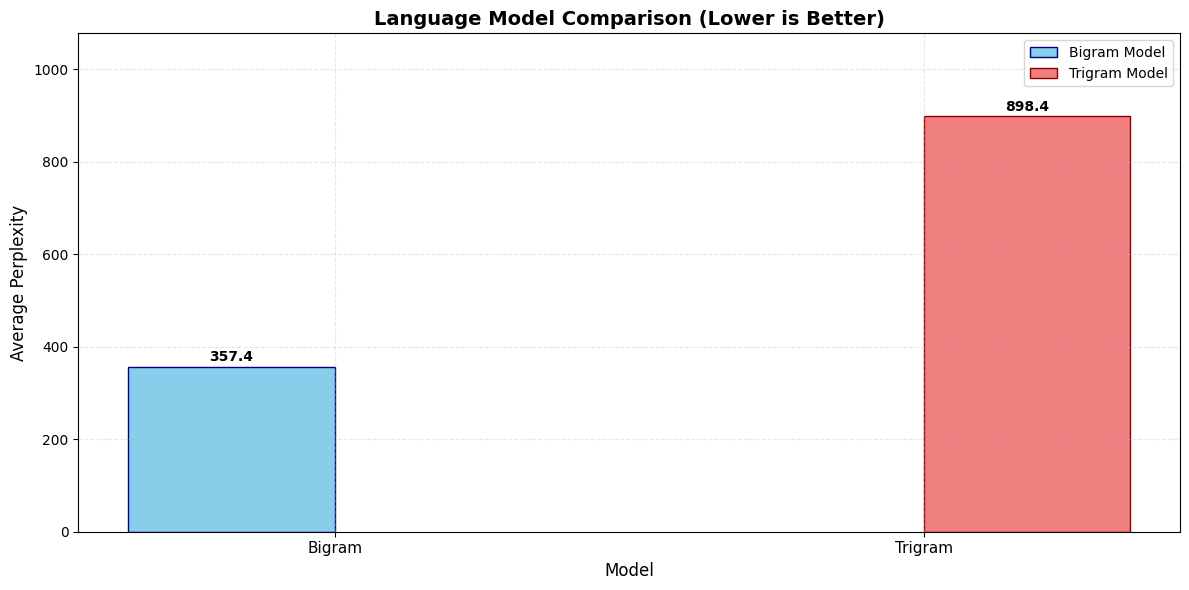

In [62]:
plt.figure(figsize=(12, 6))
# Prepare data for comparison - FIXED: using separate data for each bar
models = ['Bigram', 'Trigram']
x = np.arange(len(models))
width = 0.35
# FIXED: Using separate data arrays for each bar
plt.bar(x[0] - width/2, bigram_avg, width, 
        label='Bigram Model', color='skyblue', edgecolor='navy')
plt.bar(x[1] + width/2, trigram_avg, width,
        label='Trigram Model', color='lightcoral', edgecolor='darkred')

# Add value labels on bars
plt.text(x[0] - width/2, bigram_avg + 5, f'{bigram_avg:.1f}', 
         ha='center', va='bottom', fontweight='bold')
plt.text(x[1] + width/2, trigram_avg + 5, f'{trigram_avg:.1f}', 
         ha='center', va='bottom', fontweight='bold')

plt.xlabel('Model', fontsize=12)
plt.ylabel('Average Perplexity', fontsize=12)
plt.title('Language Model Comparison (Lower is Better)', fontsize=14, fontweight='bold')
plt.xticks(x, ['Bigram', 'Trigram'], fontsize=11)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.ylim(0, max(bigram_avg, trigram_avg) * 1.2)  # Add some headroom for labels

plt.tight_layout()
plt.savefig('model_comparison_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

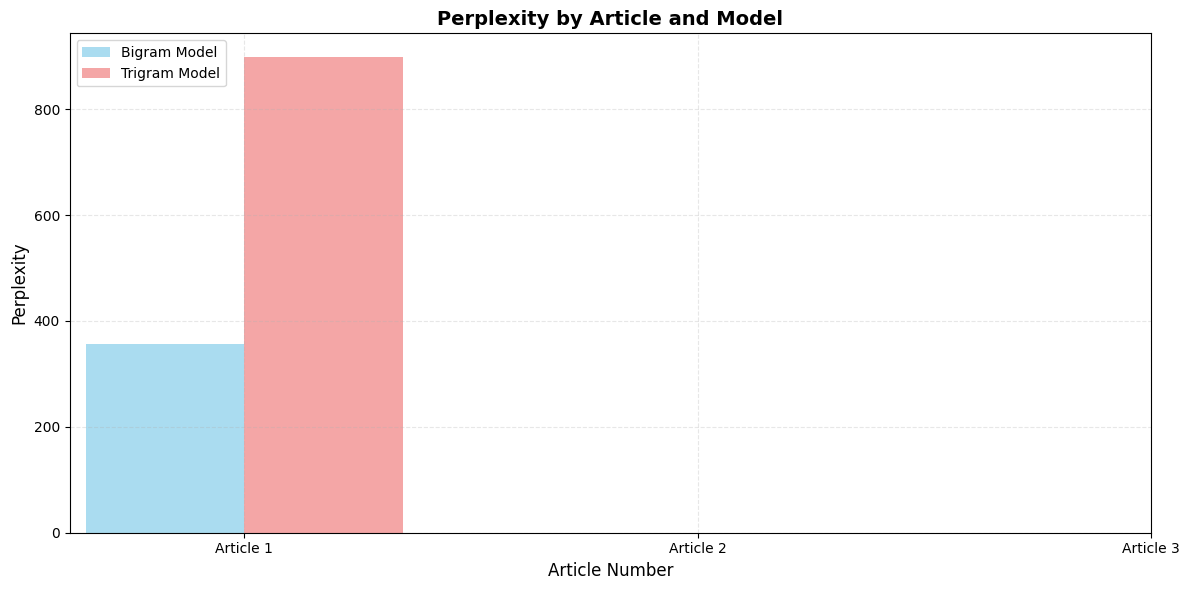

In [63]:
plt.figure(figsize=(12, 6))

# Plot individual article perplexities
x_articles = np.arange(len(bigram_articles))
width = 0.35

plt.bar(x_articles - width/2, bigram_ppl_fixed, width, 
        label='Bigram Model', color='skyblue', alpha=0.7)
plt.bar(x_articles + width/2, trigram_ppl_fixed, width,
        label='Trigram Model', color='lightcoral', alpha=0.7)

plt.xlabel('Article Number', fontsize=12)
plt.ylabel('Perplexity', fontsize=12)
plt.title('Perplexity by Article and Model', fontsize=14, fontweight='bold')
plt.xticks(x_articles, [f'Article {i+1}' for i in range(len(bigram_articles))])
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('perplexity_by_article.png', dpi=150, bbox_inches='tight')
plt.show()

In [64]:
# Analyze why some articles have inf perplexity
print("\n" + "=" * 70)
print("PERPLEXITY ANALYSIS")
print("=" * 70)

for i, article in enumerate(bigram_articles):
    tokens = nlpUrdu.tokenize_words(article)
    tokens = [t for t in tokens if t not in ['<SOS>', '<EOS>'] and t.strip()]
    # Count OOV words
    oov_count = 0
    for token in tokens:
        if token not in lm.unigram_probs:
            oov_count += 1
    oov_rate = (oov_count / len(tokens)) * 100 if tokens else 0
    print(f"\nArticle {i+1}:")
    print(f"  Total tokens: {len(tokens)}")
    print(f"  OOV words: {oov_count} ({oov_rate:.1f}%)")
    print(f"  Bigram Perplexity: {bigram_ppl_fixed[i]:.2f}")
    print(f"  Trigram Perplexity: {trigram_ppl_fixed[i]:.2f}")
    
    if oov_rate > 30:
        print(f"  Note: High OOV rate may cause infinite perplexity")

# Test with a simple sentence to verify perplexity calculation works
print("\n" + "=" * 70)
print("VERIFICATION TEST")
print("=" * 70)

test_sentence = "پاکستان میں بارش ہوئی"
test_ppl_bigram = calculate_perplexity(test_sentence, lm, 'bigram')
test_ppl_trigram = calculate_perplexity(test_sentence, lm, 'trigram')

print(f"Test sentence: {test_sentence}")
print(f"Bigram perplexity: {test_ppl_bigram:.2f}")
print(f"Trigram perplexity: {test_ppl_trigram:.2f}")

if test_ppl_bigram != float('inf') and test_ppl_trigram != float('inf'):
    print("✓ Perplexity calculation working correctly")
else:
    print("✗ Still issues with perplexity calculation")


PERPLEXITY ANALYSIS

Article 1:
  Total tokens: 161
  OOV words: 1 (0.6%)
  Bigram Perplexity: 357.37
  Trigram Perplexity: 898.38

Article 2:
  Total tokens: 1
  OOV words: 1 (100.0%)
  Bigram Perplexity: inf
  Trigram Perplexity: inf
  Note: High OOV rate may cause infinite perplexity

Article 3:
  Total tokens: 1
  OOV words: 1 (100.0%)
  Bigram Perplexity: inf
  Trigram Perplexity: inf
  Note: High OOV rate may cause infinite perplexity

VERIFICATION TEST
Test sentence: پاکستان میں بارش ہوئی
Bigram perplexity: 1560.10
Trigram perplexity: 2848.33
✓ Perplexity calculation working correctly


### ***UI Requirements (Bonus)***
The system must allow:
- Model selection (Bigram / Trigram)
- Seed input
- Article generation
- Proper Right-to-Left Urdu display


In [ ]:
# Your code here, Implement simple interactive UI
# streamlit ui code here
# Simple interactive UI
# streamlit ui code here
import streamlit as st
import time

# Configure Streamlit page
st.set_page_config(
    page_title="Urdu News Article Generator",
    page_icon="📰",
    layout="wide"
)

# Custom CSS for RTL Urdu text
st.markdown("""
<style>
.urdu-text {
    direction: rtl;
    text-align: right;
    font-family: 'Noto Nastaliq Urdu', 'Jameel Noori Nastaleeq', 'Urdu Typesetting', serif;
    font-size: 18px;
    line-height: 1.8;
    padding: 15px;
    background-color: #f8f9fa;
    border-radius: 10px;
    border-right: 5px solid #1e88e5;
    margin: 10px 0;
}
.stTextArea textarea {
    direction: rtl;
    text-align: right;
    font-family: 'Noto Nastaliq Urdu', 'Jameel Noori Nastaleeq', 'Urdu Typesetting', serif;
    font-size: 16px;
}
</style>
""", unsafe_allow_html=True)

# Title
st.title("BBC Style Urdu News Article Generator")
st.markdown("---")

# Initialize session state for generated content
if 'generated_articles' not in st.session_state:
    st.session_state.generated_articles = []
if 'generated_headlines' not in st.session_state:
    st.session_state.generated_headlines = []
if 'generator' not in st.session_state:
    st.session_state.generator = ArticleGenerator(lm)

# Create tabs
tab1, tab2, tab3 = st.tabs(["Article Generator", "Headlines", "Evaluation"])

with tab1:
    st.header("Generate News Article")
    
    # Two columns for input
    col1, col2 = st.columns([1, 1])
    
    with col1:
        # Model selection
        model_type = st.radio(
            "Select Language Model",
            options=["trigram", "bigram"],
            format_func=lambda x: "Trigram with Backoff" if x == "trigram" else "Bigram",
            horizontal=True
        )
        
        # Seed input
        seed_prompt = st.text_area(
            "Enter Seed Prompt (5-8 Urdu words)",
            height=100,
            placeholder="پاکستان میں مہنگائی کی شرح میں"
        )
        
        # Word count
        word_count = st.slider(
            "Target Article Length (words)",
            min_value=150,
            max_value=300,
            value=200,
            step=10
        )
        
        # Generate button
        generate_btn = st.button(
            "Generate Article",
            type="primary",
            use_container_width=True
        )
    
    with col2:
        st.subheader("Instructions")
        st.info(
            """
            **Guidelines:**
            - Seed must contain 5-8 Urdu words
            - Minimum 150 words
            - Maximum 300 words
            - At least 5 sentences
            - Article will be in BBC Urdu style
            
            **Example Seed:**
            پاکستان میں مہنگائی کی شرح میں
            """
        )
    
    # Generation logic
    if generate_btn:
        if seed_prompt:
            # Validate word count
            words = seed_prompt.strip().split()
            word_count_input = len(words)
            
            if word_count_input < 5:
                st.error("Seed prompt must contain at least 5 words")
            elif word_count_input > 8:
                st.error("Seed prompt must contain at most 8 words")
            else:
                # Show progress
                with st.spinner("Generating article..."):
                    # Generate article
                    article, length, sentences = st.session_state.generator.generate_article(
                        seed_prompt,
                        model_type=model_type,
                        max_words=word_count
                    )
                    
                    # Store in session state
                    st.session_state.generated_articles.append({
                        "seed": seed_prompt,
                        "model": model_type,
                        "article": article,
                        "length": length,
                        "sentences": sentences,
                        "time": time.strftime("%Y-%m-%d %H:%M:%S")
                    })
                    
                    # Display results
                    st.success("Article generated successfully!")
                    
                    # Display metrics
                    col1, col2, col3 = st.columns(3)
                    with col1:
                        st.metric("Total Words", length)
                    with col2:
                        st.metric("Sentences", sentences)
                    with col3:
                        if length < 150:
                            st.metric("Status", "Below Minimum", delta_color="inverse")
                        elif length > 300:
                            st.metric("Status", "Above Maximum", delta_color="inverse")
                        else:
                            st.metric("Status", "OK")
                    
                    # Display article
                    st.subheader("Generated Article")
                    st.markdown(f'<div class="urdu-text">{article}</div>', unsafe_allow_html=True)
        else:
            st.warning("Please enter a seed prompt")
    
    # Display history
    if st.session_state.generated_articles:
        st.markdown("---")
        st.subheader("Generation History")
        
        for i, item in enumerate(reversed(st.session_state.generated_articles[-3:])):
            with st.expander(f"Article {len(st.session_state.generated_articles) - i}: {item['seed'][:30]}..."):
                st.write(f"**Model:** {'Trigram' if item['model'] == 'trigram' else 'Bigram'}")
                st.write(f"**Words:** {item['length']} | **Sentences:** {item['sentences']}")
                st.write(f"**Time:** {item['time']}")
                st.markdown(f'<div class="urdu-text">{item["article"]}</div>', unsafe_allow_html=True)

with tab2:
    st.header("Generate News Headlines")
    
    col1, col2 = st.columns([1, 1])
    
    with col1:
        num_headlines = st.number_input(
            "Number of Headlines",
            min_value=1,
            max_value=10,
            value=5,
            step=1
        )
        
        generate_headlines_btn = st.button(
            "Generate Headlines",
            type="primary",
            use_container_width=True
        )
    
    with col2:
        st.info(
            """
            **Headline Requirements:**
            - 5-10 words each
            - BBC Urdu style
            - News-oriented content
            """
        )
    
    if generate_headlines_btn:
        with st.spinner("Generating headlines..."):
            headlines = []
            for i in range(num_headlines):
                headline = st.session_state.generator.generate_headline()
                headlines.append(headline)
                st.session_state.generated_headlines.append({
                    "headline": headline,
                    "time": time.strftime("%Y-%m-%d %H:%M:%S")
                })
        
        st.success(f"Generated {num_headlines} headlines")
        
        # Display headlines
        st.subheader("Generated Headlines")
        for i, headline in enumerate(headlines, 1):
            st.markdown(f"""
            <div style="
                direction: rtl;
                text-align: right;
                font-family: 'Noto Nastaliq Urdu', serif;
                font-size: 16px;
                padding: 10px;
                margin: 5px 0;
                background-color: {'#f0f2f6' if i % 2 == 0 else '#ffffff'};
                border-radius: 5px;
            ">
                <strong>{i}.</strong> {headline}
            </div>
            """, unsafe_allow_html=True)
    
    # Display headline history
    if st.session_state.generated_headlines:
        st.markdown("---")
        st.subheader("Recent Headlines")
        for item in reversed(st.session_state.generated_headlines[-10:]):
            st.markdown(f"""
            <div style="
                direction: rtl;
                text-align: right;
                font-family: 'Noto Nastaliq Urdu', serif;
                font-size: 14px;
                padding: 5px 10px;
                margin: 3px 0;
                background-color: #f8f9fa;
                border-radius: 3px;
            ">
                {item['headline']}
                <span style="
                    float: left;
                    font-size: 12px;
                    color: #666;
                    direction: ltr;
                ">{item['time']}</span>
            </div>
            """, unsafe_allow_html=True)

with tab3:
    st.header("Evaluation and Analysis")
    
    # Check if we have generated articles to evaluate
    if st.session_state.generated_articles:
        st.subheader("Perplexity Analysis")
        
        # Calculate perplexity for each generated article
        eval_data = []
        for article in st.session_state.generated_articles:
            ppl_bigram = calculate_perplexity(article['article'], lm, 'bigram')
            ppl_trigram = calculate_perplexity(article['article'], lm, 'trigram')
            
            eval_data.append({
                "Seed": article['seed'][:30] + "...",
                "Model Used": "Trigram" if article['model'] == 'trigram' else "Bigram",
                "Words": article['length'],
                "Sentences": article['sentences'],
                "Perplexity (Bigram)": f"{ppl_bigram:.2f}",
                "Perplexity (Trigram)": f"{ppl_trigram:.2f}"
            })
        
        # Display as dataframe
        st.dataframe(pd.DataFrame(eval_data), use_container_width=True)
        
        # Perplexity comparison chart
        st.subheader("Perplexity Comparison")
        
        # Prepare data for chart
        bigram_scores = []
        trigram_scores = []
        
        for article in st.session_state.generated_articles:
            bigram_scores.append(calculate_perplexity(article['article'], lm, 'bigram'))
            trigram_scores.append(calculate_perplexity(article['article'], lm, 'trigram'))
        
        # Create chart
        chart_data = pd.DataFrame({
            'Bigram': bigram_scores,
            'Trigram': trigram_scores
        })
        
        st.bar_chart(chart_data)
        
        st.caption("Lower perplexity indicates better model performance")
        
        # Model comparison
        st.subheader("Model Comparison")
        
        col1, col2 = st.columns(2)
        
        with col1:
            st.markdown("""
            **Bigram Model**
            - Simple word pairs
            - Faster generation
            - May produce less coherent long sentences
            """)
        
        with col2:
            st.markdown("""
            **Trigram Model with Backoff**
            - Captures longer dependencies
            - Backoff to bigram/unigram when needed
            - Generally lower perplexity
            - More natural sentence flow
            """)
    else:
        st.info("Generate some articles first to see evaluation metrics")
        
    # Statistics
    st.subheader("Model Statistics")
    
    col1, col2, col3 = st.columns(3)
    
    with col1:
        st.metric("Vocabulary Size", lm.vocab_size)
    
    with col2:
        st.metric("Unique Bigrams", len(lm.bigram_counts))
    
    with col3:
        st.metric("Unique Trigrams", len(lm.trigram_counts))

# Sidebar with information
with st.sidebar:
    st.header("About")
    st.markdown("""
    **Urdu News Article Generator**
    
    This system generates BBC-style Urdu news articles using statistical language models.
    
    **Features:**
    - Bigram Language Model
    - Trigram Language Model with Backoff
    - Laplace (Add-1) Smoothing
    - RTL Urdu Display
    - Perplexity Evaluation
    
    **Constraints:**
    - Minimum 150 words
    - Maximum 300 words
    - 5-8 word seed prompts
    - At least 5 sentences
    """)
    
    st.markdown("---")
    
    # Quick seed examples
    st.subheader("Example Seeds")
    example_seeds = [
        "پاکستان میں مہنگائی کی شرح میں",
        "وزیراعظم شہباز شریف نے کہا",
        "بلوچستان میں سیکیورٹی فورسز نے",
        "کراچی میں بارش کے بعد صورتحال",
        "پاکستان اور انڈیا کے درمیان"
    ]
    
    for seed in example_seeds:
        if st.button(seed, use_container_width=True):
            st.session_state['example_seed'] = seed
    
    st.markdown("---")
    st.caption("Assignment 1 - DS-C")
    st.caption("Language Modeling for Urdu News Articles")